In [9]:
import pandas as pd

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav_history = pd.read_csv("../data/raw/02_nav_history.csv")

In [10]:
print("FUND MASTER SHAPE:", fund_master.shape)
print("NAV HISTORY SHAPE:", nav_history.shape)

FUND MASTER SHAPE: (40, 15)
NAV HISTORY SHAPE: (46000, 3)


In [11]:
fund_master.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [12]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [13]:
print("Unique Fund Houses:")
print(fund_master["fund_house"].unique())
print("Count:", fund_master["fund_house"].nunique())

Unique Fund Houses:
<StringArray>
[         'SBI Mutual Fund',         'HDFC Mutual Fund',
      'ICICI Prudential MF',          'Nippon India MF',
        'Kotak Mahindra MF',         'Axis Mutual Fund',
 'Aditya Birla Sun Life MF',          'UTI Mutual Fund',
           'Mirae Asset MF',          'DSP Mutual Fund']
Length: 10, dtype: str
Count: 10


In [14]:
print("Unique Categories:")
print(fund_master["category"].unique())
print("Count:", fund_master["category"].nunique())

Unique Categories:
<StringArray>
['Equity', 'Debt']
Length: 2, dtype: str
Count: 2


In [15]:
print("Unique Sub-Categories:")
print(fund_master["sub_category"].unique())
print("Count:", fund_master["sub_category"].nunique())

Unique Sub-Categories:
<StringArray>
[      'Large Cap',       'Small Cap',            'Gilt',         'Mid Cap',
  'Short Duration',           'Value',          'Liquid',       'Index/ETF',
       'Flexi Cap',           'Index', 'Large & Mid Cap',            'ELSS']
Length: 12, dtype: str
Count: 12


In [20]:
print("risk_category:")
print(fund_master["risk_category"].unique())
print("Count:", fund_master["risk_category"].nunique())

risk_category:
<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str
Count: 5


In [22]:
print("sebi_category_code:")
print(fund_master["sebi_category_code"].head(10))

sebi_category_code:
0    EC01
1    EC01
2    EC03
3    EC03
4    DC02
5    EC01
6    EC01
7    EC02
8    EC02
9    DC02
Name: sebi_category_code, dtype: str


In [24]:
print(fund_master["sebi_category_code"].dtype)

str


In [25]:
fund_master["sebi_category_code"] = fund_master["sebi_category_code"].astype(str)
nav_history["amfi_code"] = nav_history["amfi_code"].astype(str)

In [26]:
fund_codes = set(fund_master["sebi_category_code"])
nav_codes = set(nav_history["amfi_code"])

In [27]:
missing_codes = fund_codes - nav_codes

print("Missing AMFI Codes Count:", len(missing_codes))
print(missing_codes)

Missing AMFI Codes Count: 9
{'EC04', 'EC06', 'EC03', 'EI01', 'EC02', 'DC01', 'EC01', 'DC02', 'EC05'}


In [28]:
extra_codes = nav_codes - fund_codes

print("Extra NAV Codes Count:", len(extra_codes))

Extra NAV Codes Count: 40


In [29]:
total_funds = len(fund_master)
total_nav_codes = len(nav_history)
missing = len(missing_codes)

print("========== DATA QUALITY SUMMARY ==========")
print("Total Funds in Master:", total_funds)
print("Total NAV Records:", total_nav_codes)
print("Missing AMFI Codes:", missing)

print("\nData Quality Status:")

if missing == 0:
    print("✅ Excellent - Complete mapping between fund master and NAV history")
elif missing < 10:
    print("⚠️ Good - Minor missing scheme codes detected")
else:
    print("❌ Poor - Significant mismatch between datasets, needs cleanup")

========== DATA QUALITY SUMMARY ==========
Total Funds in Master: 40
Total NAV Records: 46000
Missing AMFI Codes: 9

Data Quality Status:
⚠️ Good - Minor missing scheme codes detected


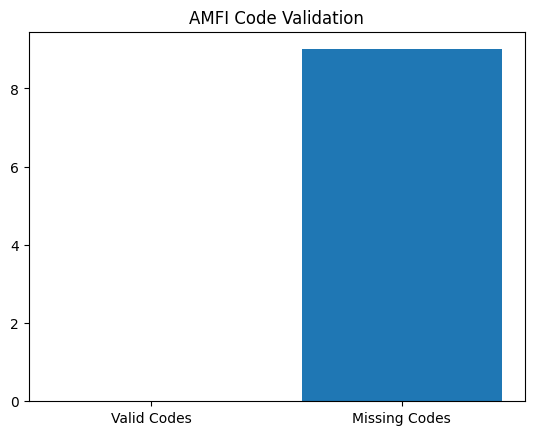

In [30]:
import matplotlib.pyplot as plt

plt.bar(["Valid Codes", "Missing Codes"], 
        [len(fund_codes)-len(missing_codes), len(missing_codes)])

plt.title("AMFI Code Validation")
plt.show()